In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import subprocess
import tempfile
import os

In [ ]:

BASE_DIR   = '/home/boussif/boussif/CM_inference/data/processed/Neu-SEA'
THRESHOLDS = [1.5, 2, 3, 4]
N_PEAKS    = 200
GENE_BED   = '/data/genome/homo_sapiens/GRCh38.102/Homo_sapiens.GRCh38.102.gtf.gene.body.bed'

CELL_TYPES = {
    'Glu':  {'out_dir': '../data/processed/results_aCM_AD_Glu'},
    'Gaba': {'out_dir': '../data/processed/results_aCM_AD_Gaba'},
}

for cfg in CELL_TYPES.values():
    os.makedirs(cfg['out_dir'], exist_ok=True)

def acm_path(cell_type, bg):
    return f'{BASE_DIR}/3.aCM_scores/{cell_type}/n_peaks_{N_PEAKS}/bg_threshold_{bg}/aCM_matrix/sign_corrected_aCM_matrix.bed'

def content_path(cell_type, bg):
    return f'{BASE_DIR}/1.clomics_CMs/{cell_type}/n_peaks_{N_PEAKS}/bg_threshold_{bg}/SEA-AD-Neu/SEA-AD-Neu_Clomics_CM_batches.content.txt'

def tracks_path(cell_type, bg):
    return f'{BASE_DIR}/1.clomics_CMs/{cell_type}/n_peaks_{N_PEAKS}/bg_threshold_{bg}/SEA-AD-Neu/SEA-AD-Neu_Clomics_CM.tracks.bed'

def run_correlation(acm_df, phenotype):
    """Spearman correlation of each CM row against a phenotype vector (aligned)."""
    results = []
    common = acm_df.columns.intersection(phenotype.index)
    ph = phenotype.loc[common]
    for cm_id, row in acm_df[common].iterrows():
        r, p = stats.spearmanr(row.values, ph.values)
        results.append({'CM': cm_id, 'rho': r, 'pval': p})
    df = pd.DataFrame(results).set_index('CM')
    reject, padj, _, _ = multipletests(df['pval'], method='fdr_bh')
    df['padj'] = padj
    return df


In [9]:
# --- Load metadata ---
meta_df = pd.read_csv('../data/metadata/metadata.txt', sep='\t', index_col=0)
pps = meta_df['Continuous_Pseudo-progression_Score'].dropna()
cog_status = meta_df['Cognitive_Status'].dropna()
print(f"Donors avec PPS: {len(pps)}")
print(f"Cognitive status: {cog_status.value_counts().to_dict()}")

Donors avec PPS: 73
Cognitive status: {'No dementia': 41, 'Dementia': 32, 'Reference': 2}


In [ ]:

# --- Load all aCM matrices and run correlations ---
# all_acm_dicts : cell_type -> {bg -> acm DataFrame}
# all_res_dicts : cell_type -> {bg -> correlation results DataFrame}
all_acm_dicts = {}
all_res_dicts = {}

for cell_type, cfg in CELL_TYPES.items():
    print(f"\n{'='*60}")
    print(f"=== {cell_type} ===")
    acm_dict = {}
    res_dict = {}
    for bg in THRESHOLDS:
        path = acm_path(cell_type, bg)
        if not os.path.exists(path):
            print(f"  bg={bg}: MANQUANT ({path})")
            continue
        acm_df = pd.read_csv(path, sep='\t', index_col=0)
        acm_dict[bg] = acm_df
        res_dict[bg] = run_correlation(acm_df, pps)
        n_sig   = (res_dict[bg]['padj'] < 0.1).sum()
        n_open  = ((res_dict[bg]['padj'] < 0.1) & (res_dict[bg]['rho'] > 0)).sum()
        n_close = ((res_dict[bg]['padj'] < 0.1) & (res_dict[bg]['rho'] < 0)).sum()
        print(f"  bg={bg}: {len(acm_df)} CMs | FDR<0.1: {n_sig} (↑{n_open} ↓{n_close})")
    all_acm_dicts[cell_type] = acm_dict
    all_res_dicts[cell_type] = res_dict



=== Glu ===


TypeError: acm_path() missing 1 required positional argument: 'cell_type'

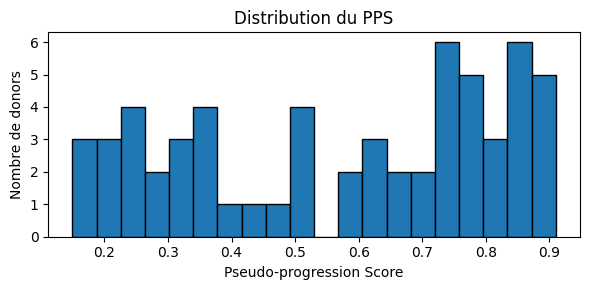

In [ ]:

ref_bg = THRESHOLDS[0]
ref_acm = next(iter(all_acm_dicts.values()))  # premiers donors disponibles
pps_aligned = pps.loc[pps.index.intersection(ref_acm[ref_bg].columns)]

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(pps_aligned.values, bins=20, edgecolor='black')
ax.set_xlabel('Pseudo-progression Score')
ax.set_ylabel('Nombre de donors')
ax.set_title('Distribution du PPS (donors communs)')
plt.tight_layout()
plt.savefig(f'{CELL_TYPES["Glu"]["out_dir"]}/pps_distribution.png', dpi=150)
plt.show()


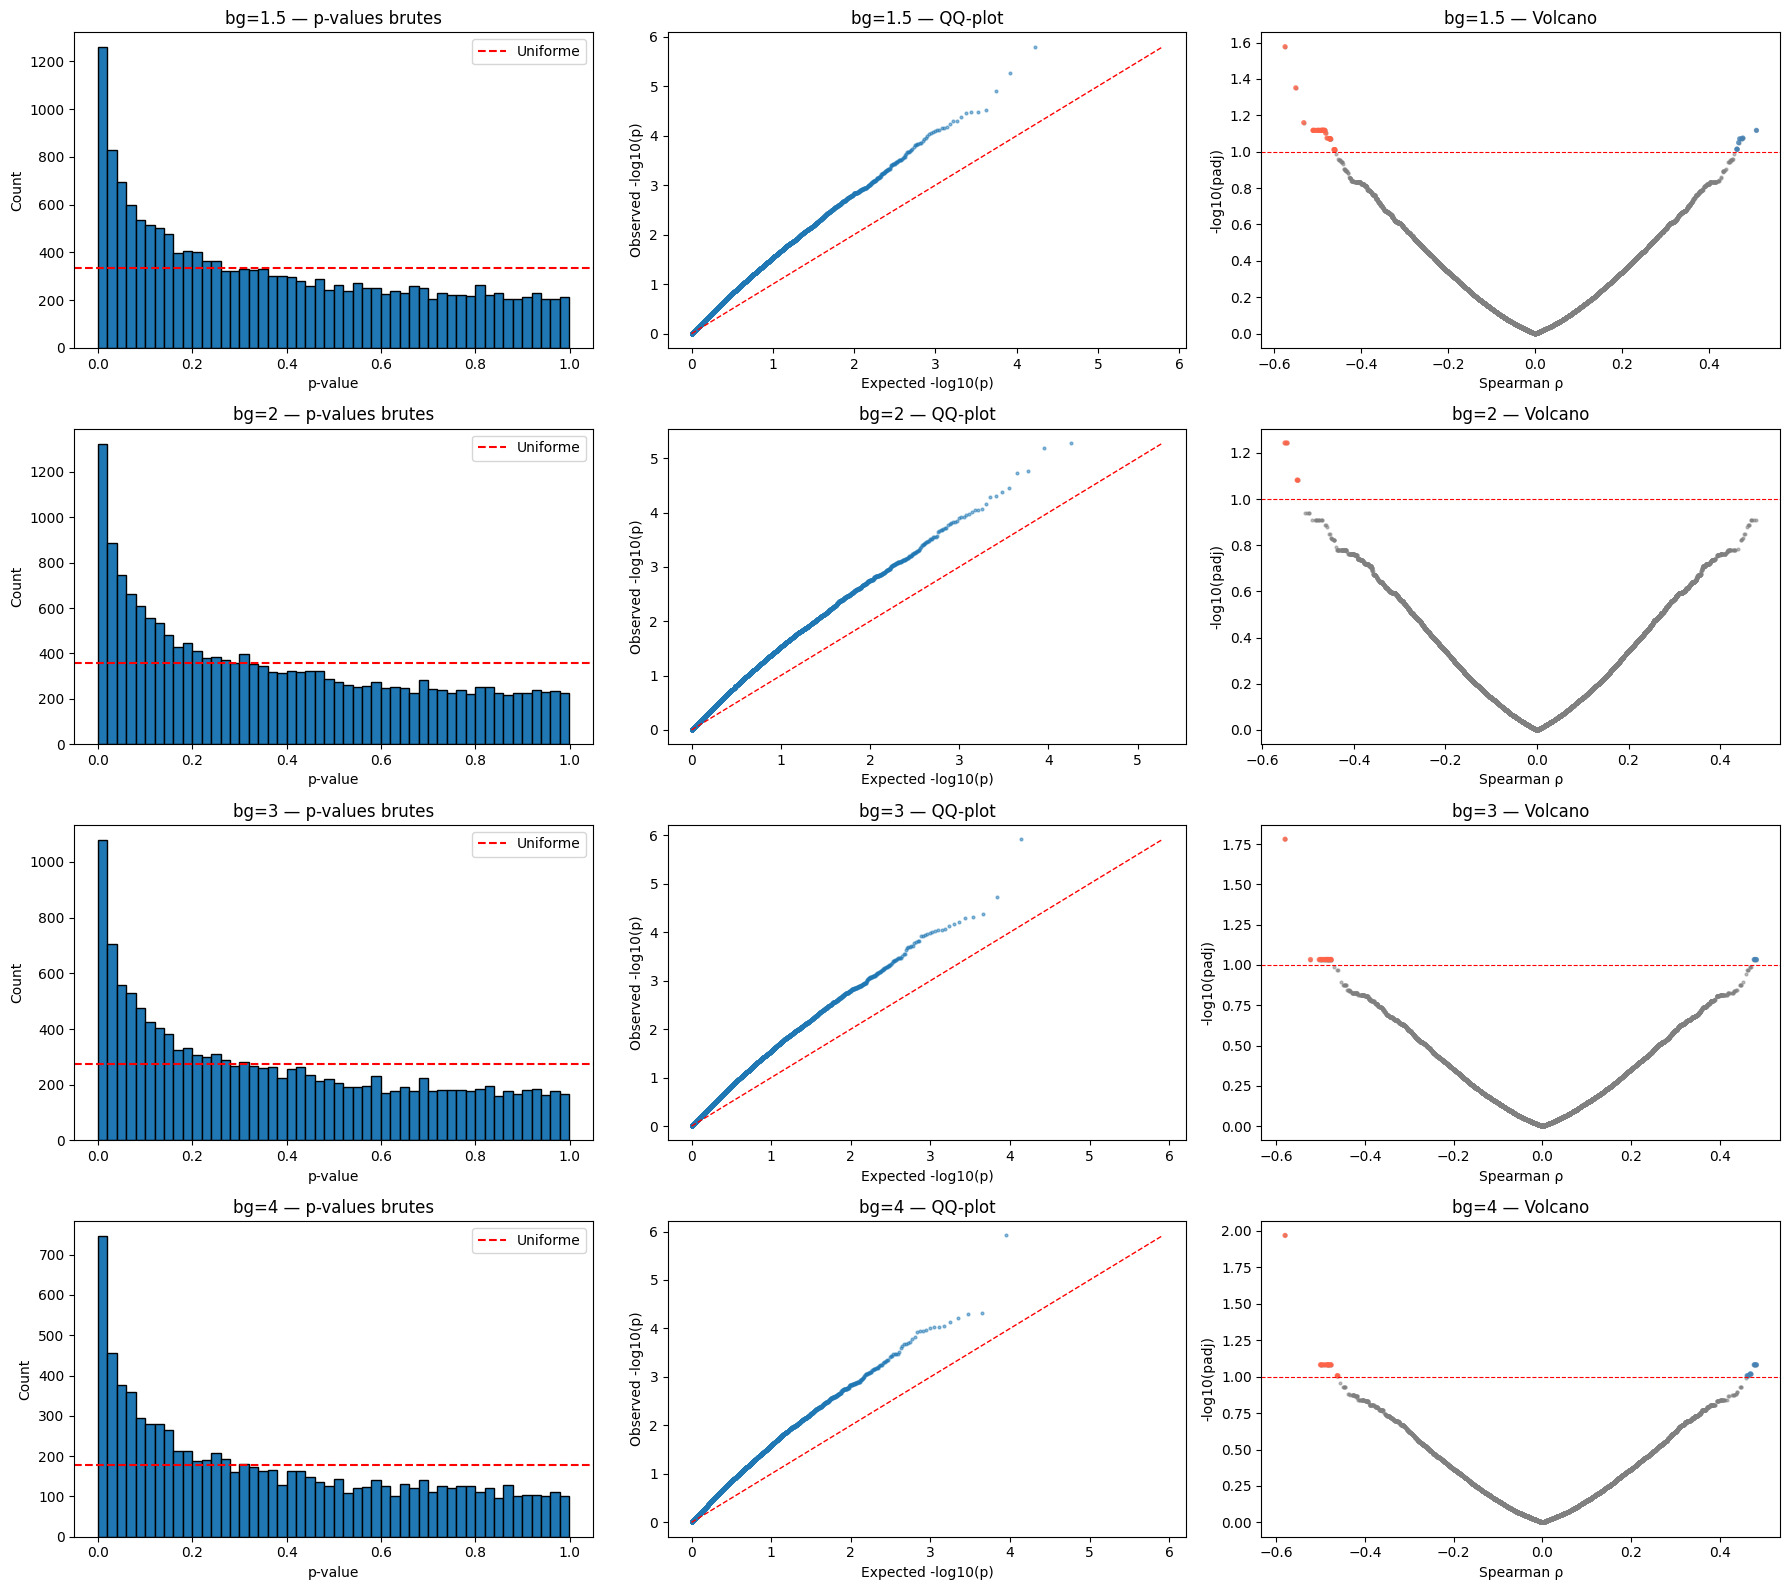

In [ ]:

# ============================================================================
# QQ-plots & p-value distributions — all thresholds × all cell types
# ============================================================================
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    res_dict = all_res_dicts[cell_type]
    bgs      = list(res_dict.keys())
    if not bgs:
        print(f"{cell_type}: aucun résultat disponible")
        continue

    fig, axes = plt.subplots(len(bgs), 3, figsize=(18, 4 * len(bgs)))
    if len(bgs) == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f'QQ-plots & Volcanos — {cell_type}', fontsize=13, fontweight='bold')

    for i, bg in enumerate(bgs):
        res = res_dict[bg]

        # P-value distribution
        axes[i, 0].hist(res['pval'], bins=50, edgecolor='black')
        axes[i, 0].axhline(y=len(res)/50, color='red', linestyle='--', label='Uniforme')
        axes[i, 0].set_xlabel('p-value')
        axes[i, 0].set_ylabel('Count')
        axes[i, 0].set_title(f'bg={bg} — p-values brutes')
        axes[i, 0].legend()

        # QQ-plot
        observed = -np.log10(np.sort(res['pval'].values))
        expected = -np.log10(np.linspace(1/len(res), 1, len(res)))
        axes[i, 1].scatter(expected, observed, s=4, alpha=0.5)
        max_val = max(expected.max(), observed.max())
        axes[i, 1].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
        axes[i, 1].set_xlabel('Expected -log10(p)')
        axes[i, 1].set_ylabel('Observed -log10(p)')
        axes[i, 1].set_title(f'bg={bg} — QQ-plot')

        # Volcano plot
        axes[i, 2].scatter(res['rho'], -np.log10(res['padj']), s=4, alpha=0.5, c='grey')
        sig = res[res['padj'] < 0.1]
        if len(sig) > 0:
            colors = ['steelblue' if r > 0 else 'tomato' for r in sig['rho']]
            axes[i, 2].scatter(sig['rho'], -np.log10(sig['padj']), s=8, alpha=0.7, c=colors)
        axes[i, 2].axhline(-np.log10(0.1), color='red', linestyle='--', linewidth=0.8)
        axes[i, 2].set_xlabel('Spearman ρ')
        axes[i, 2].set_ylabel('-log10(padj)')
        axes[i, 2].set_title(f'bg={bg} — Volcano')

    plt.tight_layout()
    plt.savefig(f'{out_dir}/all_thresholds_qqplot_volcano.png', dpi=150)
    plt.show()


In [ ]:

# ============================================================================
# Seuils alternatifs — tableau récapitulatif par type cellulaire
# ============================================================================
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    res_dict = all_res_dicts[cell_type]
    print(f"\n{'='*50}\n=== {cell_type} ===")

    rows = []
    for bg, res in res_dict.items():
        row = {'bg_threshold': bg, 'total_CMs': len(res)}
        for seuil in [0.1, 0.05, 0.01, 0.001]:
            row[f'padj<{seuil}'] = (res['padj'] < seuil).sum()
            row[f'pval<{seuil}'] = (res['pval'] < seuil).sum()
        rows.append(row)

    summary_table = pd.DataFrame(rows).set_index('bg_threshold')
    print(summary_table.to_string())
    summary_table.to_csv(f'{out_dir}/threshold_summary.csv')


              total_CMs  padj<0.1  pval<0.1  padj<0.05  pval<0.05  padj<0.01  pval<0.01  padj<0.001  pval<0.001
bg_threshold                                                                                                   
1.5               16711        37      3916          2       2421          0        745           0         108
2.0               17945         4      4228          0       2626          0        740           0         105
3.0               13777        18      3347          1       2088          0        620           0          87
4.0                8909        19      2233          1       1398          0        435           0          61


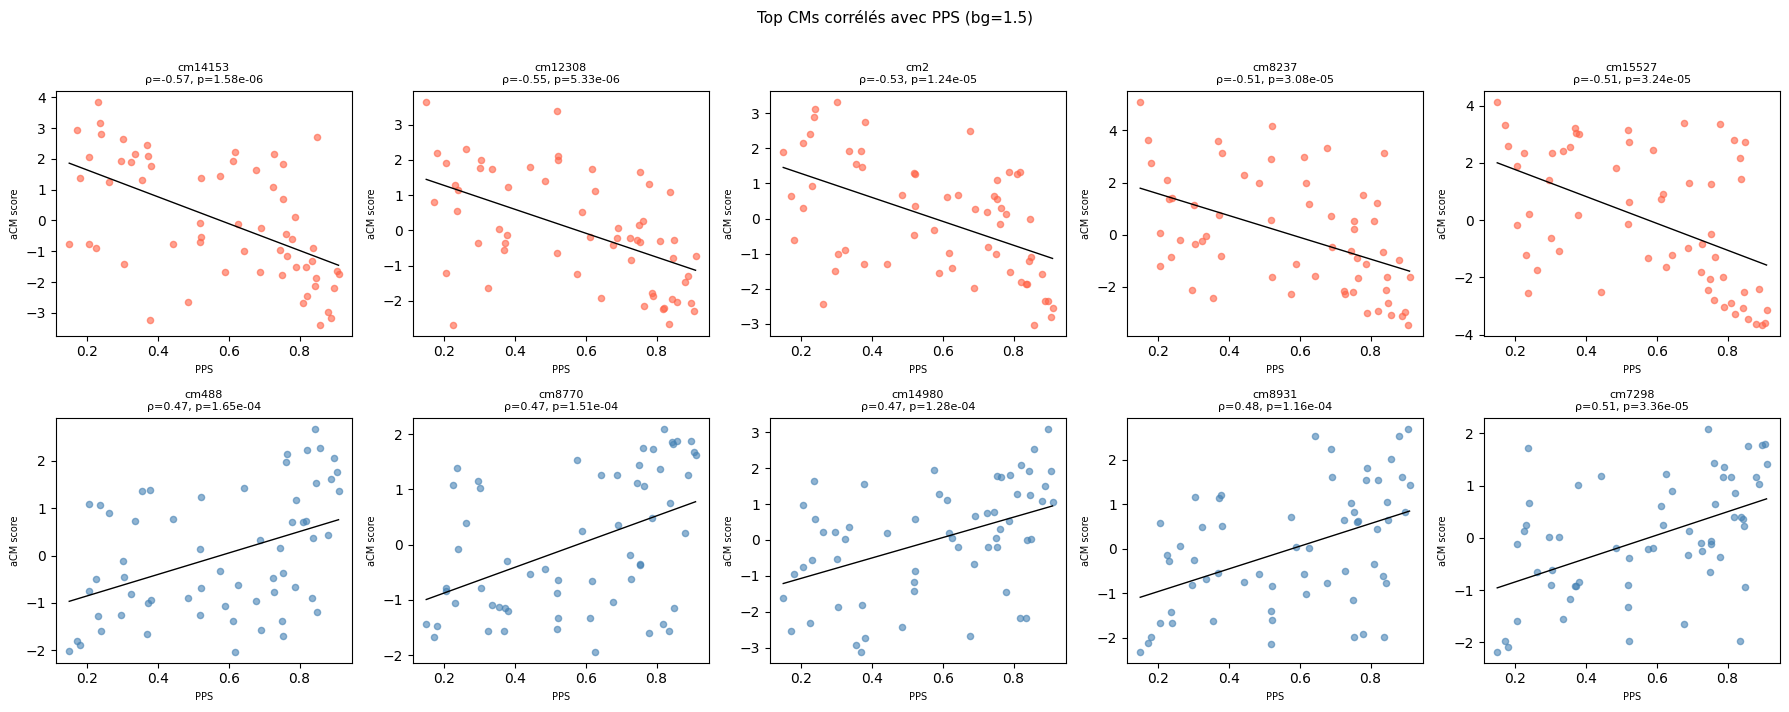

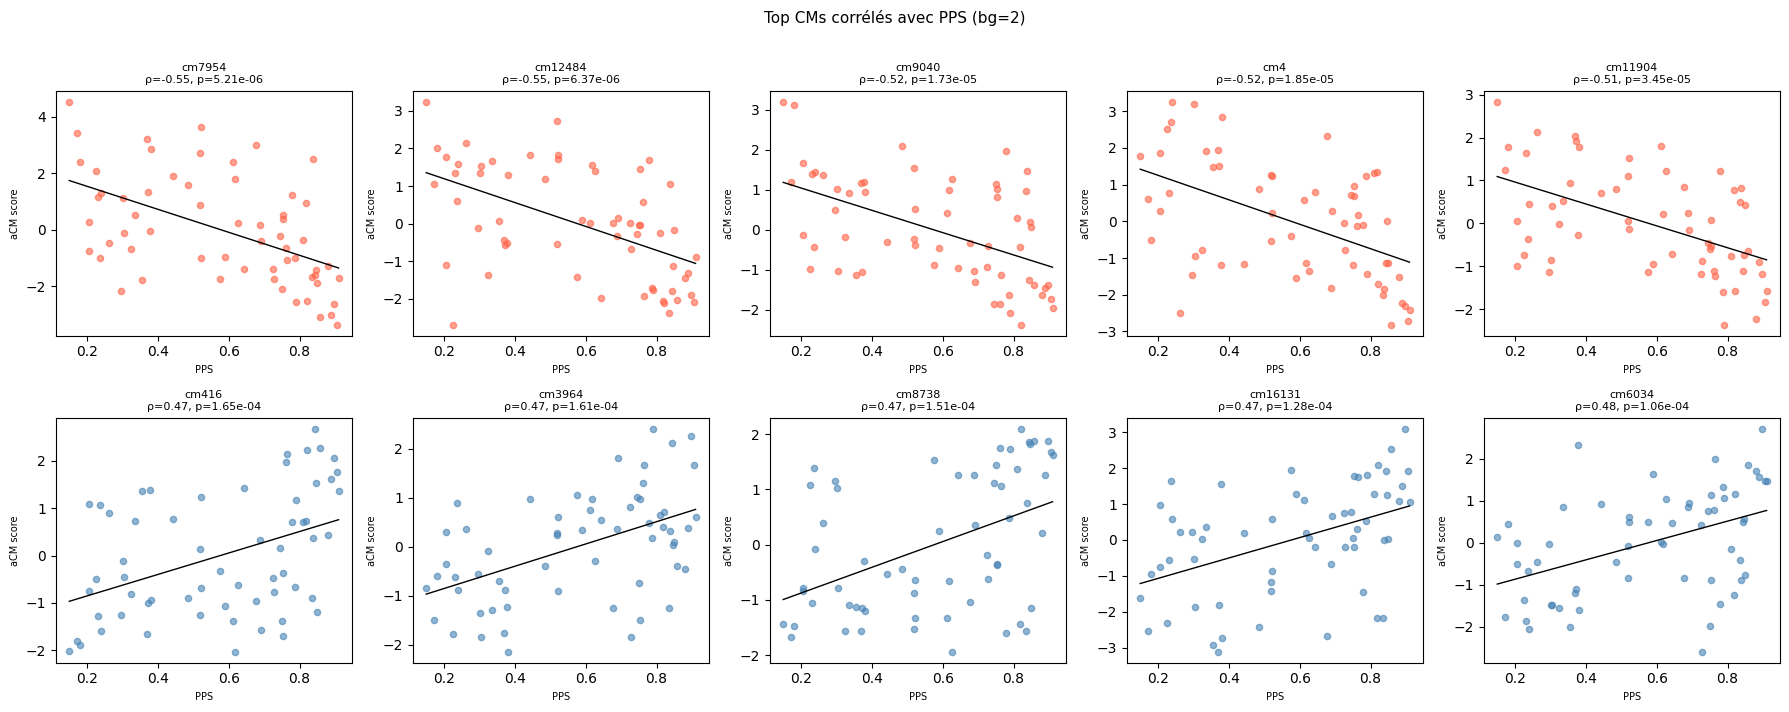

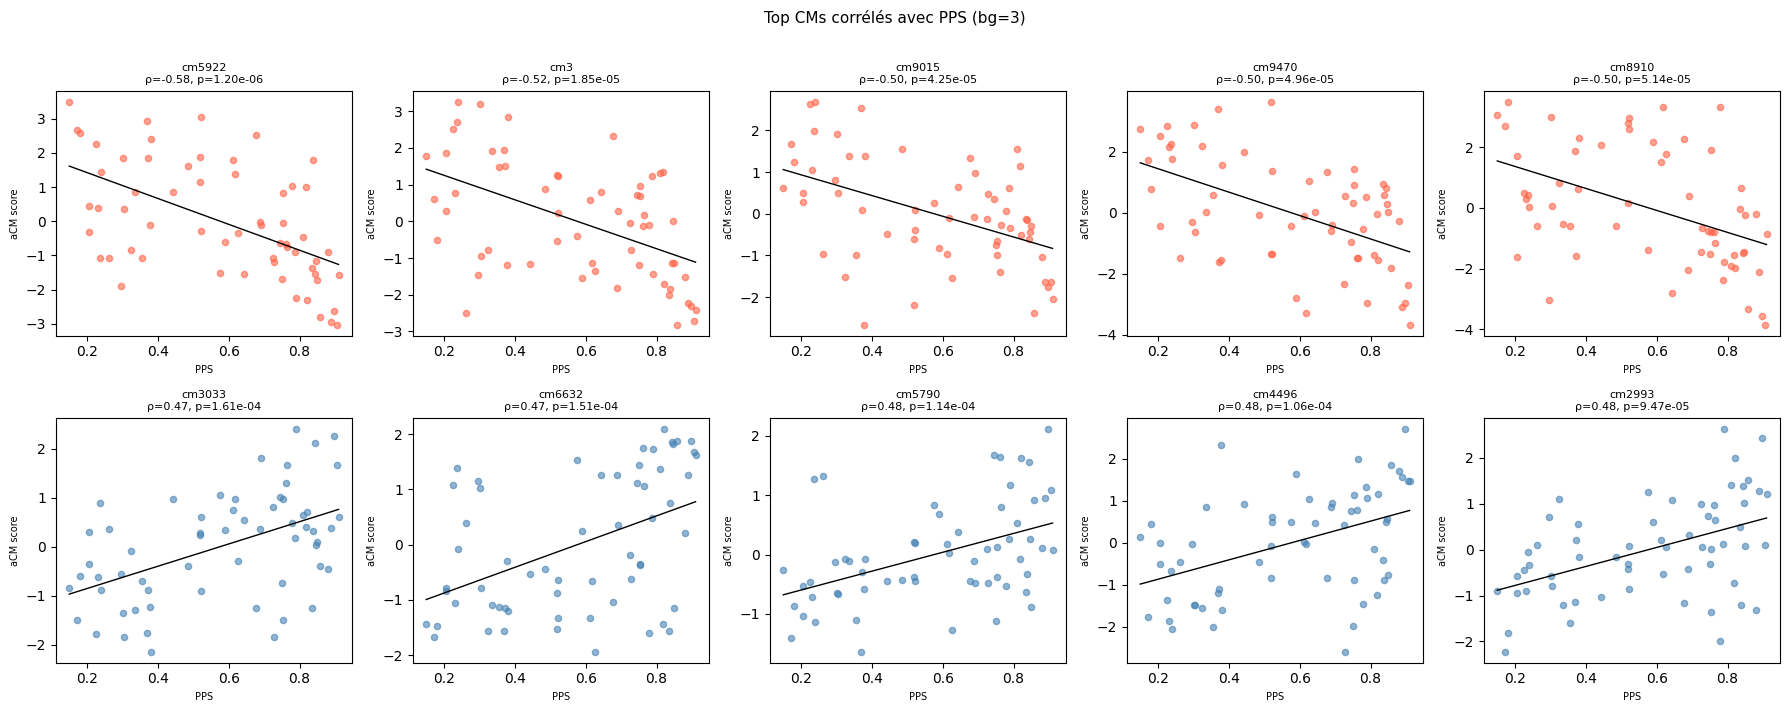

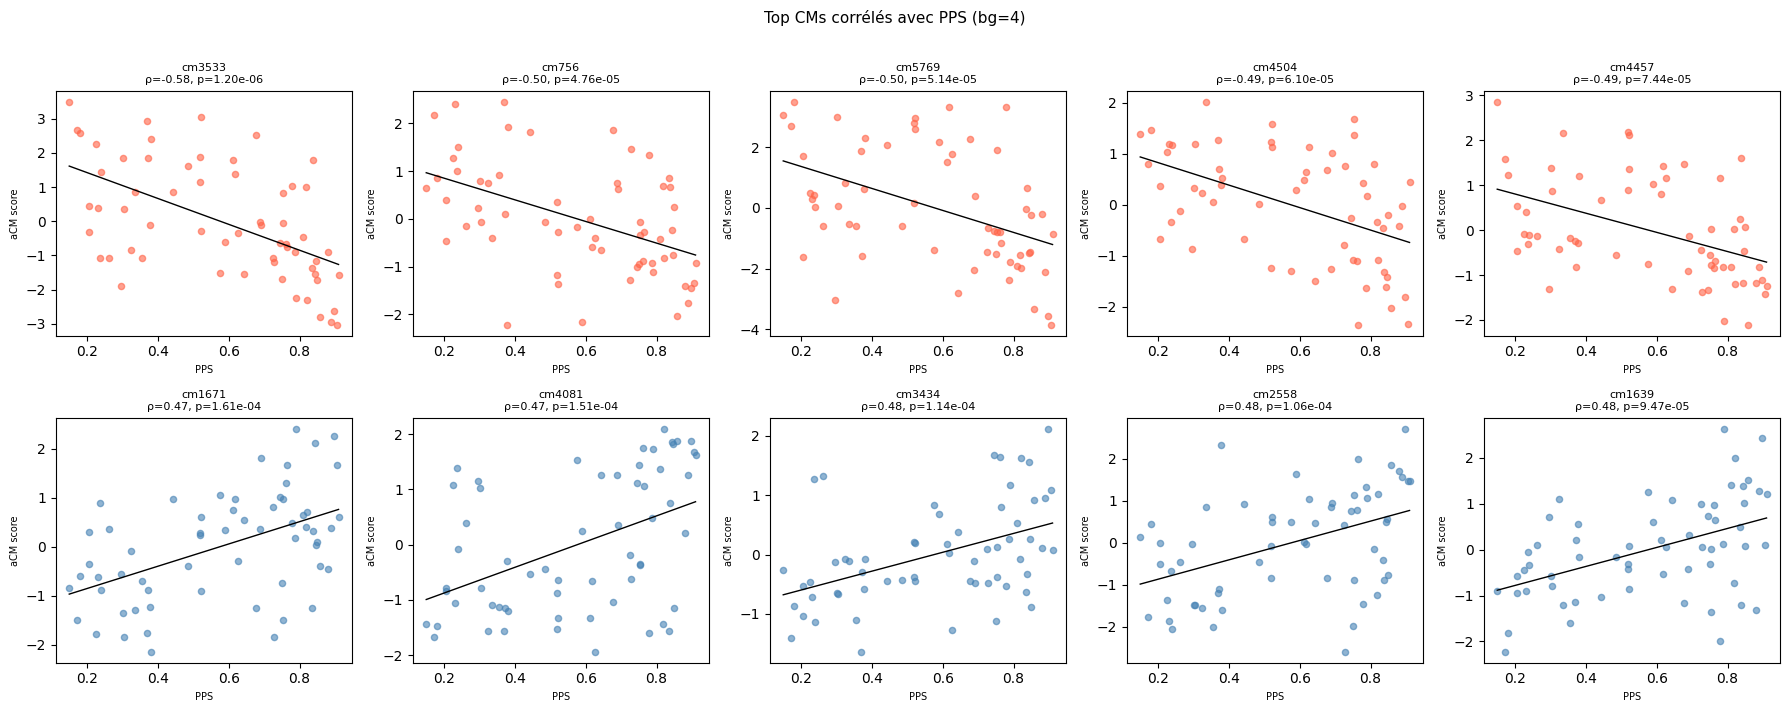

In [ ]:

# ============================================================================
# Top CMs scatter plots — per threshold × per cell type
# ============================================================================
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    acm_dict = all_acm_dicts[cell_type]
    res_dict = all_res_dicts[cell_type]

    for bg, res in res_dict.items():
        acm_df    = acm_dict[bg]
        candidates = res[res['pval'] < 0.001].sort_values('rho')
        common_col = acm_df.columns.intersection(pps_aligned.index)
        pps_bg     = pps_aligned.loc[common_col]

        if len(candidates) < 10:
            top_closing = candidates.head(min(5, len(candidates))).index.tolist()
            top_opening = candidates.tail(min(5, len(candidates))).index.tolist()
        else:
            top_closing = candidates.head(5).index.tolist()
            top_opening = candidates.tail(5).index.tolist()

        top_cms = list(dict.fromkeys(top_closing + top_opening))
        n_cms   = len(top_cms)
        if n_cms == 0:
            print(f"{cell_type} bg={bg}: No CMs with pval < 0.001")
            continue

        ncols = min(5, n_cms)
        nrows = (n_cms + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.5 * nrows), squeeze=False)

        for i, cm_id in enumerate(top_cms):
            ax  = axes[i // ncols][i % ncols]
            x   = pps_bg.values
            y   = acm_df.loc[cm_id, pps_bg.index].values
            rho = candidates.loc[cm_id, 'rho']
            p   = candidates.loc[cm_id, 'pval']
            ax.scatter(x, y, alpha=0.6, s=20, color='steelblue' if rho > 0 else 'tomato')
            z = np.polyfit(x, y, 1)
            xline = np.linspace(x.min(), x.max(), 100)
            ax.plot(xline, np.poly1d(z)(xline), color='black', linewidth=1)
            ax.set_title(f'{cm_id}\nρ={rho:.2f}, p={p:.2e}', fontsize=8)
            ax.set_xlabel('PPS', fontsize=7)
            ax.set_ylabel('aCM score', fontsize=7)

        for j in range(n_cms, nrows * ncols):
            axes[j // ncols][j % ncols].axis('off')

        plt.suptitle(f'Top CMs corrélés avec PPS — {cell_type} (bg={bg})', fontsize=11, y=1.01)
        plt.tight_layout()
        plt.savefig(f'{out_dir}/top_cms_scatter_bg{bg}.png', dpi=150)
        plt.show()


In [ ]:

# all_sig_cms : cell_type -> {bg -> sig DataFrame}
all_sig_cms = {}

for cell_type, cfg in CELL_TYPES.items():
    res_dict = all_res_dicts[cell_type]
    sig_cms  = {}
    for bg, res in res_dict.items():
        sig = res[(res['padj'] < 0.1) & (abs(res['rho']) > 0.3)]
        sig_cms[bg] = sig
    all_sig_cms[cell_type] = sig_cms

    if sig_cms:
        union_sig = pd.concat(sig_cms.values()).index.unique()
    else:
        union_sig = pd.Index([])
    print(f"{cell_type} — Union sig CMs (padj<0.1, |rho|>0.3): {len(union_sig)}")
    for bg, sig in sig_cms.items():
        print(f"  bg={bg}: {len(sig)} sig")


Union sig CMs: 78


In [ ]:

for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    res_dict = all_res_dicts[cell_type]
    sig_cms  = all_sig_cms[cell_type]

    if not sig_cms:
        print(f"{cell_type}: aucun CM significatif")
        continue

    union_sig = pd.concat(sig_cms.values()).index.unique()

    union_sig_df = pd.DataFrame()
    for bg, res in res_dict.items():
        available = union_sig.intersection(res.index)
        bg_df = res.loc[available].copy()
        bg_df['bg'] = bg
        union_sig_df = pd.concat([union_sig_df, bg_df])

    union_sig_df = union_sig_df[~union_sig_df.index.duplicated(keep='first')]
    union_sig_df.to_csv(f'{out_dir}/sig_cms_padj01_rho03.csv')
    print(f"{cell_type} ✅ {union_sig_df.shape[0]} CMs sig sauvegardés → {out_dir}/sig_cms_padj01_rho03.csv")
    print(union_sig_df.head())


✅ Sauvegardé: (78, 4) (CMs x stats+bg)
             rho      pval      padj   bg
CM                                       
cm2    -0.531537  0.000012  0.069214  1.5
cm488   0.467574  0.000165  0.089155  1.5
cm2141  0.463907  0.000189  0.096868  1.5
cm3395 -0.485524  0.000084  0.076310  1.5
cm4037 -0.483412  0.000091  0.076310  1.5


In [ ]:

# all_cm_peaks : cell_type -> {cm_bg_key -> [peaks]}
all_cm_peaks = {}

for cell_type, cfg in CELL_TYPES.items():
    sig_cms  = all_sig_cms[cell_type]
    cm_peaks = {}

    print(f"\n{'='*50}\n=== {cell_type} ===")
    for bg, sig_this_bg_df in sig_cms.items():
        sig_this_bg = sig_this_bg_df.index
        cpath = content_path(cell_type, bg)
        print(f"\n--- bg={bg} ---")
        if not os.path.exists(cpath):
            print("MANQUANT")
            continue

        df_content = pd.read_csv(cpath, sep='\t', header=None,
                                 names=['CM_full', 'nb_peaks', 'peaks_str'])
        df_content['CM'] = df_content['CM_full'].str.split('_').str[0]
        print(f"Sig CE bg: {len(sig_this_bg)}")

        found = 0
        for cm in sig_this_bg:
            if cm in df_content['CM'].values:
                peaks_str  = df_content[df_content['CM'] == cm]['peaks_str'].iloc[0]
                peaks_list = [p.strip() for p in peaks_str.split(',')]
                cm_peaks[f"{cm}_bg{bg}"] = peaks_list
                found += 1
        print(f"Match content: {found}/{len(sig_this_bg)}")

    all_cm_peaks[cell_type] = cm_peaks
    print(f"\n✅ {cell_type} TOTAL: {len(cm_peaks)} CMs (bg-spécifiques)")



--- bg=1.5 ---
Sig CE bg: 37
Match content: 37/37

--- bg=2 ---
Sig CE bg: 4
Match content: 4/4

--- bg=3 ---
Sig CE bg: 18
Match content: 18/18

--- bg=4 ---
Sig CE bg: 19
Match content: 19/19

✅ TOTAL: 78 (bg-spécifiques)


In [ ]:

# BED de tous les peaks — un fichier par type cellulaire
for cell_type, cfg in CELL_TYPES.items():
    out_dir  = cfg['out_dir']
    cm_peaks = all_cm_peaks[cell_type]
    all_peaks_bed = []

    for cm_bg, peaks_list in cm_peaks.items():
        cm_id = cm_bg.split('_bg')[0]
        for peak in peaks_list:
            parts = peak.split(':')
            chrom = parts[1]
            start = int(parts[2])
            end   = int(parts[3])
            all_peaks_bed.append([chrom, start, end, cm_id, cm_bg])

    if not all_peaks_bed:
        print(f"{cell_type}: aucun peak à exporter")
        continue

    peaks_df = pd.DataFrame(all_peaks_bed, columns=['chr', 'start', 'end', 'CM', 'CM_bg'])
    peaks_df.to_csv(f'{out_dir}/sig_cms_all_peaks.bed', sep='\t', index=False, header=False)
    print(f"{cell_type} ✅ BED: {len(peaks_df)} peaks pour {len(cm_peaks)} CMs")
    print(peaks_df.head())


✅ BED créé: 227 peaks pour 78 CMs
    chr     start       end     CM        CM_bg
0  chr1    875757    877326    cm2    cm2_bg1.5
1  chr1    996901   1006150    cm2    cm2_bg1.5
2  chr1   1012743   1017171    cm2    cm2_bg1.5
3  chr1  54571391  54572116  cm488  cm488_bg1.5
4  chr1  54579361  54584296  cm488  cm488_bg1.5
227 /home/boussif/boussif/SEA-AD/MTG_scATAC/results_aCM_AD/78cms_all_peaks.bed


In [ ]:

# Bedtools intersect peaks → gènes — un fichier par type cellulaire
for cell_type, cfg in CELL_TYPES.items():
    out_dir    = cfg['out_dir']
    peaks_raw  = f'{out_dir}/sig_cms_all_peaks.bed'
    peaks_fixed = f'{out_dir}/sig_cms_all_peaks_FIXED.bed'
    genes_bed   = f'{out_dir}/sig_cms_peaks_to_genes.bed'

    if not os.path.exists(peaks_raw):
        print(f"{cell_type}: fichier BED manquant, ignoré")
        continue

    # Fix chr prefix
    peaks_df = pd.read_csv(peaks_raw, sep='\t', header=None,
                           names=['chr', 'start', 'end', 'CM', 'CM_bg'])
    peaks_df['chr'] = peaks_df['chr'].str.replace('chr', '', regex=False)
    peaks_df.to_csv(peaks_fixed, sep='\t', index=False, header=False)
    print(f"{cell_type} — chr fixed ({len(peaks_df)} peaks)")

    cmd = f"bedtools intersect -wa -wb -a {peaks_fixed} -b {GENE_BED} > {genes_bed}"
    subprocess.run(cmd, shell=True)
    n_lines = int(subprocess.run(f"wc -l < {genes_bed}", shell=True, capture_output=True, text=True).stdout.strip())
    print(f"{cell_type} ✅ {n_lines} overlaps → {genes_bed}")


✅ chr fixed:   chr   start      end   CM      CM_bg
0   1  875757   877326  cm2  cm2_bg1.5
1   1  996901  1006150  cm2  cm2_bg1.5
228 /home/boussif/boussif/SEA-AD/MTG_scATAC/results_aCM_AD/78cms_peaks_to_genes.bed
1	875757	877326	cm2	cm2_bg1.5	1	874529	877234	ENSG00000283040~AL669831.5	1000	-
1	875757	877326	cm2	cm2_bg1.5	1	868071	876903	ENSG00000230368~FAM41C	1000	-
1	996901	1006150	cm2	cm2_bg1.5	1	995966	998051	ENSG00000272512~AL645608.7	1000	-


In [ ]:

# Parse gene overlaps → table propre — par type cellulaire
all_results = {}

for cell_type, cfg in CELL_TYPES.items():
    out_dir   = cfg['out_dir']
    genes_bed = f'{out_dir}/sig_cms_peaks_to_genes.bed'

    if not os.path.exists(genes_bed):
        print(f"{cell_type}: fichier gene BED manquant, ignoré")
        continue

    gene_hits = pd.read_csv(genes_bed, sep='\t', header=None,
                            names=['chr_p', 'start_p', 'end_p', 'CM', 'CM_bg',
                                   'chr_g', 'start_g', 'end_g', 'gene_id', 'score', 'strand'])
    gene_hits['gene_name'] = gene_hits['gene_id'].str.split('~').str[1]
    gene_hits['ensembl']   = gene_hits['gene_id'].str.split('~').str[0]

    result = gene_hits[['CM', 'CM_bg', 'chr_p', 'start_p', 'end_p', 'gene_name', 'ensembl', 'strand']]
    result.to_csv(f'{out_dir}/sig_cms_to_genes_CLEAN.csv', index=False)
    all_results[cell_type] = result

    print(f"\n=== {cell_type} ===")
    print(f"  Shape: {result.shape}")
    print(f"  Gènes uniques    : {result['gene_name'].nunique()}")
    print(f"  CMs avec gènes   : {result['CM'].nunique()}")
    print(result.head(5))


Shape: (228, 8)
       CM         CM_bg  chr_p   start_p     end_p   gene_name  \
0     cm2     cm2_bg1.5      1    875757    877326  AL669831.5   
1     cm2     cm2_bg1.5      1    875757    877326      FAM41C   
2     cm2     cm2_bg1.5      1    996901   1006150  AL645608.7   
3     cm2     cm2_bg1.5      1    996901   1006150       ISG15   
4     cm2     cm2_bg1.5      1    996901   1006150        HES4   
5     cm2     cm2_bg1.5      1   1012743   1017171       ISG15   
6     cm2     cm2_bg1.5      1   1012743   1017171  AL645608.1   
7   cm488   cm488_bg1.5      1  54571391  54572116      ACOT11   
8   cm488   cm488_bg1.5      1  54579361  54584296      ACOT11   
9  cm2141  cm2141_bg1.5      2  61841161  61841764     FAM161A   

           ensembl strand  
0  ENSG00000283040      -  
1  ENSG00000230368      -  
2  ENSG00000272512      -  
3  ENSG00000187608      +  
4  ENSG00000188290      -  
5  ENSG00000187608      +  
6  ENSG00000224969      -  
7  ENSG00000162390      +  
8  EN

In [ ]:

# Résumé: 1 ligne par CM avec tous ses gènes — par type cellulaire
for cell_type, cfg in CELL_TYPES.items():
    out_dir = cfg['out_dir']
    if cell_type not in all_results:
        continue
    result = all_results[cell_type]

    cm_gene_summary = result.groupby(['CM', 'CM_bg', 'strand'])['gene_name'].apply(list).reset_index()
    cm_gene_summary['nb_genes'] = cm_gene_summary['gene_name'].apply(len)
    cm_gene_summary.to_csv(f'{out_dir}/sig_cms_gene_summary.csv', index=False)

    print(f"\n=== {cell_type} ===")
    print(cm_gene_summary.head(5))
    print(f"Stats gènes/CM:")
    print(cm_gene_summary.groupby('CM')['nb_genes'].sum().describe())
    print(f"✅ Sauvegardé → {out_dir}/sig_cms_gene_summary.csv")


        CM          CM_bg strand  \
0  cm10401    cm10401_bg3      +   
1  cm10401    cm10401_bg3      -   
2  cm10661  cm10661_bg1.5      +   
3  cm11022  cm11022_bg1.5      +   
4  cm11209  cm11209_bg1.5      +   
5  cm11561  cm11561_bg1.5      +   
6  cm12070  cm12070_bg1.5      +   
7  cm12070  cm12070_bg1.5      -   
8  cm12306  cm12306_bg1.5      +   
9  cm12306  cm12306_bg1.5      -   

                                           gene_name  nb_genes  
0                  [LINC00640, LINC00640, LINC00640]         3  
1               [AL358332.1, AL358332.1, AL358332.1]         3  
2                                 [HMX3, HMX3, HMX2]         3  
3  [MIR129-2, AC068205.1, AC068205.2, AC068205.1,...         5  
4                                            [CCND1]         1  
5                                       [AP001994.3]         1  
6                                          [DNAJC22]         1  
7                                     [C1QL4, C1QL4]         2  
8  [AC010201.3, AC